# Hierarchical grid stats

Loads the u16 LiDAR export into the Rust `RayTracer` (`rust/src/grid.rs`). It is a recursive tree in which each node splits its area into 3×3 children: leaves hold 3×3 points, the level above them 9×9 points, and so on up to a single root. Subtrees with no points (ocean, empty parcel slots, padding up to `3^depth`) are stored as `None`.

Run with the **viewfinder-backend** kernel, which has `viewfinder_core` built. The export must already exist (see `export-f16.ipynb`).

In [1]:
import pathlib
import resource
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from viewfinder_core import RayTracer

u16_path = pathlib.Path("~/data/lidar-vancouver-u16").expanduser()

start = time.perf_counter()
rt = RayTracer(u16_path)
load_seconds = time.perf_counter() - start
stats = rt.stats()
rt

RayTracer(rows=28000, columns=38000, depth=10, cell_size=0.5, missing=65535)

In [2]:
index = pd.read_csv(u16_path / "index.csv")
alt_min, alt_max = rt.alt_range
grid_points = rt.rows * rt.columns
pd.Series({
    "load time (s)": round(load_seconds, 1),
    "peak process RSS (GiB)": round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 2**20, 2),
    "parcels loaded": len(index),
    "grid (rows x columns)": f"{rt.rows} x {rt.columns}",
    "area covered (km)": f"{rt.rows * rt.cell_size / 1000:g} x {rt.columns * rt.cell_size / 1000:g}",
    "cell size (m)": rt.cell_size,
    "NW point (UTM 10N)": f"{rt.x_start}, {rt.y_start}",
    "tree depth": rt.depth,
    "root side (points)": 3 ** rt.depth,
    "altitude range (m)": f"{alt_min} .. {alt_max}",
    "altitude step (mm)": round((alt_max - alt_min) / 65534 * 1000, 2),
}, name="value").to_frame()

,value
load time (s),5.4
peak process RSS (GiB),7.01
parcels loaded,181
grid (rows x columns),28000 x 38000
area covered (km),14 x 19
cell size (m),0.5
NW point (UTM 10N),"480000.25, 5462999.75"
tree depth,10
root side (points),59049
altitude range (m),-10.816 .. 588.35


In [3]:
# One row per tree level, root first. A node at level L covers 3^(depth - L) points per side.
levels = pd.DataFrame({
    "nodes": stats.nodes_per_level,
    "empty child slots": stats.empty_slots_per_level,
})
levels.index.name = "level"
levels["kind"] = ["Subcells"] * (rt.depth - 1) + ["Points (leaf)"]
levels["points per side"] = [3 ** (rt.depth - level) for level in levels.index]
levels["side (m)"] = levels["points per side"] * rt.cell_size
levels["fill vs full tree"] = levels["nodes"] / 9.0 ** levels.index
levels.style.format({"nodes": "{:,}", "empty child slots": "{:,}", "points per side": "{:,}", "side (m)": "{:,.1f}", "fill vs full tree": "{:.1%}"})

,nodes,empty child slots,kind,points per side,side (m),fill vs full tree
level,,,,,,
0,1,0,Subcells,"59,049","29,524.5",100.0%
1,4,5,Subcells,"19,683","9,841.5",44.4%
2,25,11,Subcells,"6,561","3,280.5",30.9%
3,182,43,Subcells,"2,187","1,093.5",25.0%
4,"1,472",166,Subcells,729,364.5,22.4%
5,"12,546",702,Subcells,243,121.5,21.2%
6,"111,119","1,795",Subcells,81,40.5,20.9%
7,"991,540","8,531",Subcells,27,13.5,20.7%
8,"8,879,551","44,309",Subcells,9,4.5,20.6%


In [4]:
leaf_points = stats.nodes_per_level[-1] * 9
raw_u16_bytes = len(index) * index["width"].iloc[0] * index["height"].iloc[0] * 2
pd.Series({
    "points in the grid": f"{grid_points:,}",
    "points with data": f"{stats.points_present:,} ({stats.points_present / grid_points:.1%})",
    "points stored in leaves": f"{leaf_points:,}",
    "missing points inside leaves": f"{stats.points_missing_in_leaves:,} ({stats.points_missing_in_leaves / leaf_points:.1%} of leaf slots)",
    "tree memory (GiB)": round(stats.tree_bytes / 2**30, 2),
    "u16 files on disk (GiB)": round(raw_u16_bytes / 2**30, 2),
    "tree bytes per point with data": round(stats.tree_bytes / stats.points_present, 2),
}, name="value").to_frame()

,value
points in the grid,"1,064,000,000"
points with data,"660,459,015 (62.1%)"
points stored in leaves,"705,559,446"
missing points inside leaves,"45,100,431 (6.4% of leaf slots)"
tree memory (GiB),3.96
u16 files on disk (GiB),1.35
tree bytes per point with data,6.44


In [5]:
# Check tree lookups against the raw u16 files at random points
rng = np.random.default_rng(0)
checked = mismatches = 0
for _, tile in index.sample(20, random_state=0).iterrows():
    values = np.fromfile(u16_path / tile["file"], dtype="<u2").reshape(tile["height"], tile["width"])
    row0 = round((rt.y_start - tile["y_start"]) / rt.cell_size)
    col0 = round((tile["x_start"] - rt.x_start) / rt.cell_size)
    for r, c in rng.integers(0, tile["width"], size=(500, 2)):
        v = values[r, c]
        expected = None if v == 65535 else alt_min + v / 65534 * (alt_max - alt_min)
        got = rt.altitude(row0 + r, col0 + c)
        mismatches += (got is None) != (expected is None) or (got is not None and abs(got - expected) > 1e-9)
        checked += 1
print(f"{checked} lookups, {mismatches} mismatches")

# altitude_at uses UTM coordinates: the NW point of the most complete parcel
full = index.loc[index["n_missing"].idxmin()]
print(full["name"], rt.altitude_at(full["x_start"], full["y_start"]))

10000 lookups, 0 mismatches
498000_5451000 119.23156590472121


2,660,000 lookups in 0.3 s (104 ns each)


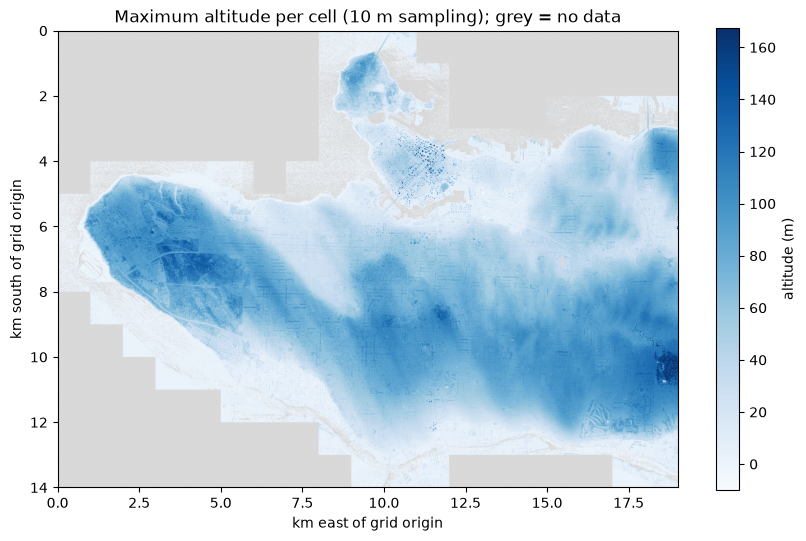

In [6]:
# Overview: every 20th point (10 m spacing) looked up through the tree
step = 20
start = time.perf_counter()
overview = np.array([
    [np.nan if (a := rt.altitude(r, c)) is None else a for c in range(0, rt.columns, step)]
    for r in range(0, rt.rows, step)
])
elapsed = time.perf_counter() - start
print(f"{overview.size:,} lookups in {elapsed:.1f} s ({elapsed / overview.size * 1e9:.0f} ns each)")

extent_km = [0, rt.columns * rt.cell_size / 1000, rt.rows * rt.cell_size / 1000, 0]
fig, ax = plt.subplots(figsize=(10, 7.5))
# Clip the colour scale at the 99.9th percentile so a few stray spikes don't wash out the city
cmap = plt.get_cmap("Blues").with_extremes(bad="#d9d9d9")  # grey so no-data differs from sea level
image = ax.imshow(overview, cmap=cmap, extent=extent_km, vmin=np.nanmin(overview), vmax=np.nanpercentile(overview, 99.9))
ax.set_title("Maximum altitude per cell (10 m sampling); grey = no data")
ax.set_xlabel("km east of grid origin")
ax.set_ylabel("km south of grid origin")
fig.colorbar(image, ax=ax, label="altitude (m)", shrink=0.8)
plt.show()

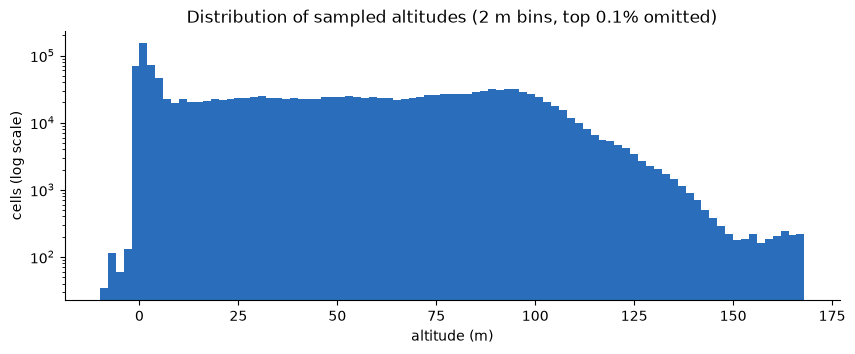

,altitude (m)
count,1650314.00
mean,49.78
std,37.53
min,-9.98
1%,-0.92
25%,12.53
50%,48.85
75%,82.54
99%,126.75
99.9%,167.40


In [7]:
present = overview[~np.isnan(overview)]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(present, bins=np.arange(np.floor(present.min()), np.percentile(present, 99.9) + 2, 2), color="#2a6ebb")
ax.set_yscale("log")
ax.set_title("Distribution of sampled altitudes (2 m bins, top 0.1% omitted)")
ax.set_xlabel("altitude (m)")
ax.set_ylabel("cells (log scale)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

pd.Series(present).describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999]).round(2).to_frame("altitude (m)")